In [1]:
!pip install pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 24.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('mymoviedb.csv',lineterminator = '\n')

In [4]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   str    
 1   Title              9827 non-null   str    
 2   Overview           9827 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   str    
 7   Genre              9827 non-null   str    
 8   Poster_Url         9827 non-null   str    
dtypes: float64(2), int64(1), str(6)
memory usage: 691.1 KB


In [7]:
df['Genre'].head()

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: str

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


>> exploration summary


<< we have data of 9827 rows and 9 columns
<< no duplicate and null values
<< for required analysis overview, original lang.,poster url is not required so we drop them.
<< noticiable outlier in popularity column
<< vote_average better considered for proper analysis
<< gener column has comma seperated values and white spaces that need to be handled and casted in category


In [9]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [10]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'])

print(df['Release_Date'].dtypes)

datetime64[us]


In [11]:
df['Release_Date'] = df['Release_Date'].dt.year
df['Release_Date'].dtypes

dtype('int32')

In [12]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


Dropping the Columns

In [13]:
cols = ['Overview' , 'Original_Language' , 'Poster_Url']

In [14]:
df.drop(cols,axis = 1,inplace = True)
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='str')

In [15]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


**categorizing Vote_Average column**

we would cut the vote_average values and  make 4 categories: **popular**,**average**,**below_avg**,**not_popular** using **categorize_col()** function

**user defined function**

In [16]:
def categorize_col(df, col, labels):

    edges = [df[col].describe()['min'],
             df[col].describe()['25%'],
             df[col].describe()['50%'],
             df[col].describe()['75%'],
             df[col].describe()['max']]
    df[col] = pd.cut(df[col],edges , labels = labels, duplicates = 'drop')
    return df
                         
                

In [17]:
labels = ['not_popular' , 'below_avg' , 'average' , 'popluar']

categorize_col(df, 'Vote_Average', labels)

df['Vote_Average'].unique()

['popluar', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, str): ['not_popular' < 'below_avg' < 'average' < 'popluar']

In [18]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popluar,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popluar,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popluar,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [19]:
df['Vote_Average'].value_counts()

Vote_Average
not_popular    2467
popluar        2450
average        2412
below_avg      2398
Name: count, dtype: int64

In [20]:
df.dropna(inplace = True)
df.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

In [21]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popluar,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popluar,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popluar,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


# split geners to list to have only one zener per row for each movie

In [22]:
df[['Title','Genre']].head()

,Title,Genre
0,Spider-Man: No Way Home,"Action, Adventure, Science Fiction"
1,The Batman,"Crime, Mystery, Thriller"
2,No Exit,Thriller
3,Encanto,"Animation, Comedy, Family, Fantasy"
4,The King's Man,"Action, Adventure, Thriller, War"


In [23]:
df['Genre'] = df['Genre'].str.split(',')

df = df.explode('Genre').reset_index(drop = True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popluar,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popluar,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popluar,Science Fiction
3,2022,The Batman,3827.658,1151,popluar,Crime
4,2022,The Batman,3827.658,1151,popluar,Mystery


In [24]:
# casting column in category

df['Genre'] = df['Genre'].astype('category')
df['Genre'].dtypes

CategoricalDtype(categories=[' Action', ' Adventure', ' Animation', ' Comedy', ' Crime',
                  ' Documentary', ' Drama', ' Family', ' Fantasy', ' History',
                  ' Horror', ' Music', ' Mystery', ' Romance',
                  ' Science Fiction', ' TV Movie', ' Thriller', ' War',
                  ' Western', 'Action', 'Adventure', 'Animation', 'Comedy',
                  'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy',
                  'History', 'Horror', 'Music', 'Mystery', 'Romance',
                  'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=str)

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25552 non-null  int32   
 1   Title         25552 non-null  str     
 2   Popularity    25552 non-null  float64 
 3   Vote_Count    25552 non-null  int64   
 4   Vote_Average  25552 non-null  category
 5   Genre         25552 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), str(1)
memory usage: 749.2 KB


In [26]:
df.nunique()

Release_Date     100
Title           9415
Popularity      8088
Vote_Count      3265
Vote_Average       4
Genre             38
dtype: int64

In [27]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popluar,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popluar,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popluar,Science Fiction
3,2022,The Batman,3827.658,1151,popluar,Crime
4,2022,The Batman,3827.658,1151,popluar,Mystery


In [ ]:
sns.set_style('whitegrid')

In [43]:
df['Genre'] = df['Genre'].str.strip()

df['Genre'].value_counts().head(20)

Genre
Drama              3715
Comedy             3006
Action             2652
Thriller           2473
Adventure          1829
Romance            1461
Horror             1457
Animation          1426
Family             1405
Fantasy            1295
Science Fiction    1255
Crime              1235
Mystery             765
History             426
War                 307
Music               291
TV Movie            214
Documentary         203
Western             137
Name: count, dtype: int64

# what is the most frequent genre of movies released on netflix?


In [42]:
df['Genre'].describe()

count     25552
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

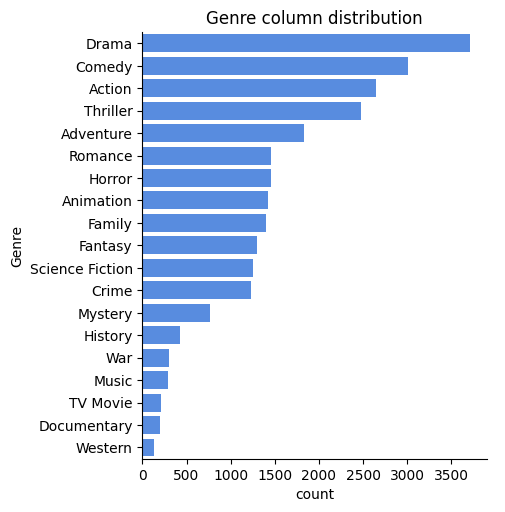

In [41]:
            
sns.catplot(y = 'Genre',data = df, kind ='count',
            order = df['Genre'].value_counts().index,
            color ='#4287f5')
plt.title('Genre column distribution')
plt.show()

# which hass highest votes in vote avg. column?

In [44]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popluar,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popluar,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popluar,Science Fiction
3,2022,The Batman,3827.658,1151,popluar,Crime
4,2022,The Batman,3827.658,1151,popluar,Mystery


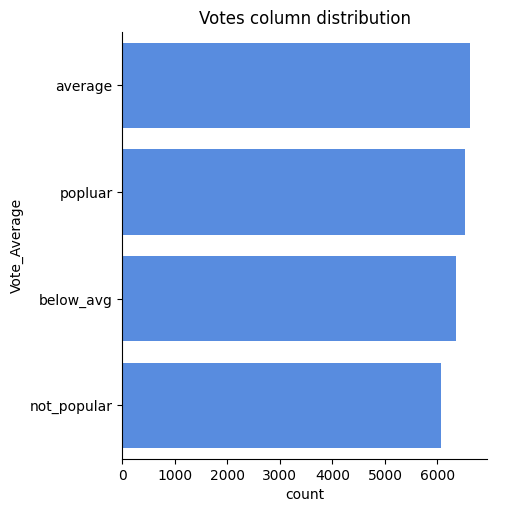

In [45]:
sns.catplot(y= 'Vote_Average',data = df , kind = 'count',
            order = df['Vote_Average'].value_counts().index,
            color ='#4287f5')
plt.title('Votes column distribution')
plt.show()

# what movie got the highest popularity? what is its genre?

In [46]:
df.head(5)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popluar,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popluar,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popluar,Science Fiction
3,2022,The Batman,3827.658,1151,popluar,Crime
4,2022,The Batman,3827.658,1151,popluar,Mystery


In [47]:
df[df['Popularity'] == df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popluar,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popluar,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popluar,Science Fiction


# which movie got the lowest popularity? what is its genre?

In [48]:
df.head(10)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popluar,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popluar,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popluar,Science Fiction
3,2022,The Batman,3827.658,1151,popluar,Crime
4,2022,The Batman,3827.658,1151,popluar,Mystery
5,2022,The Batman,3827.658,1151,popluar,Thriller
6,2022,No Exit,2618.087,122,below_avg,Thriller
7,2021,Encanto,2402.201,5076,popluar,Animation
8,2021,Encanto,2402.201,5076,popluar,Comedy
9,2021,Encanto,2402.201,5076,popluar,Family


In [49]:
df[df['Popularity'] == df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25546,2021,The United States vs. Billie Holiday,13.354,152,average,Music
25547,2021,The United States vs. Billie Holiday,13.354,152,average,Drama
25548,2021,The United States vs. Billie Holiday,13.354,152,average,History
25549,1984,Threads,13.354,186,popluar,War
25550,1984,Threads,13.354,186,popluar,Drama
25551,1984,Threads,13.354,186,popluar,Science Fiction


# which is the year of most filmmed movies?

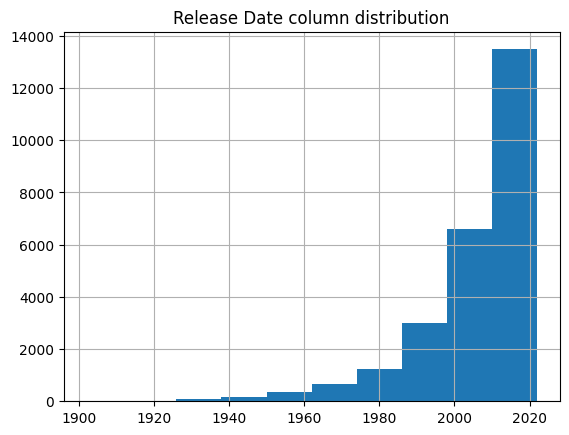

In [50]:
df['Release_Date'].hist()
plt.title('Release Date column distribution')
plt.show()

In [ ]:
Q1. What is the most frequent genre of movies in the dataset?
Answer:The most frequent genre in the dataset is Drama. It appears 3,715 times, making it the most common movie genre among all records.

Q2. Which Gener has highest votes?
Answer:The Drama category has the highest number of movies in the Vote Average column ie, 25.5%, indicates that most movies in the dataset received above-average audience ratings.

Q3. What movie has the highest popularity and what is its genre?
Answer:The movie with the highest popularity is Spider-Man: No Way Home (2021) with a popularity score of 5083.954. it has genres Action,Adventure and Science Fiction

Q4. Which movie has the lowest popularity and what is its genre?
Answer:Two movies share the lowest popularity score of 13.354:The United States vs. Billie Holiday (2021), its geners are music, drama,sci-fic,threads

Q5. Which year has the highest number of movies released?

Answer:Based on the Release year 2020 has highest filming rate in our data set.
